<div class="alert alert-block alert-info"><h1 style="text-align:center;color:black"> Cats Vs Dogs Classification using CNN 🐱🐶🚀 </h1> </div>

This notebook builds a Convolutional Neural Network (CNN) from scratch to classify images of **cats** and **dogs**, using the Microsoft Cats vs Dogs dataset.

**Dataset used:** `PetImages` folder (Cat/ and Dog/ subfolders, ~12,500 images each) from the Microsoft Cats vs Dogs dataset, already attached as Kaggle input.

**Note:** The Stanford Dogs Dataset (also attached) is **not used** here since it only contains dog breed images with no cat class — it's ignored entirely for this binary classification task.

**Known data issue:** The PetImages folders contain a small number of corrupted image files and a non-image `Thumbs.db` file in each class folder. Since `/kaggle/input` is read-only, we don't delete these — instead we validate every file while building our dataframe and simply skip anything that isn't a loadable image.

### Table of Contents
1. Loading Libraries 📖
2. Building the Valid File List (filtering corrupted files)
3. Data Exploration (class distribution + sample images)
4. Train / Validation / Test Split (stratified)
5. Image Data Generators (augmentation)
6. CNN Model Architecture
7. Callbacks (EarlyStopping + ReduceLROnPlateau)
8. Compile & Train the Model
9. Save the Trained Model
10. Training Curves (accuracy/loss)
11. Evaluation (train/val/test accuracy)
12. Classification Report & Confusion Matrix
13. Visualizing Test Predictions
14. Single-Image Prediction Function (live demo)

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Loading Libraries 📖 </h2> </div>

In [1]:
# Basic
import os
import random
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visuals
import matplotlib.pyplot as plt
import seaborn as sns

# Image handling
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # avoid crashing on slightly truncated files

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Building the Valid File List 🧹 </h2> </div>

We scan the `Cat` and `Dog` folders and keep only files that open successfully as images. Corrupted files and `Thumbs.db` are skipped (not deleted, since `/kaggle/input` is read-only).

In [2]:
# Base path to the dataset (already attached as Kaggle input, read-only)
base_dir = "/kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages"

categories = ["Cat", "Dog"]

filepaths = []
labels = []
skipped = []

for category in categories:
    folder = os.path.join(base_dir, category)
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)

        # Skip known non-image files like Thumbs.db
        if fname.lower() == "thumbs.db":
            skipped.append(fpath)
            continue

        # Validate that the file is actually a readable image
        try:
            with Image.open(fpath) as img:
                img.verify()  # checks integrity without fully loading
            filepaths.append(fpath)
            labels.append(category)
        except Exception:
            skipped.append(fpath)

data = pd.DataFrame({"filepath": filepaths, "label": labels})

print(f"Total valid images: {len(data)}")
print(f"Skipped (corrupted/non-image) files: {len(skipped)}")
data.head()

Total valid images: 24998
Skipped (corrupted/non-image) files: 4


,filepath,label
0,/kaggle/input/datasets/shaunthesheep/microsoft...,Cat
1,/kaggle/input/datasets/shaunthesheep/microsoft...,Cat
2,/kaggle/input/datasets/shaunthesheep/microsoft...,Cat
3,/kaggle/input/datasets/shaunthesheep/microsoft...,Cat
4,/kaggle/input/datasets/shaunthesheep/microsoft...,Cat


<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Data Exploration 🔍 </h2> </div>

Let's check the class balance and look at a few sample images from each class.

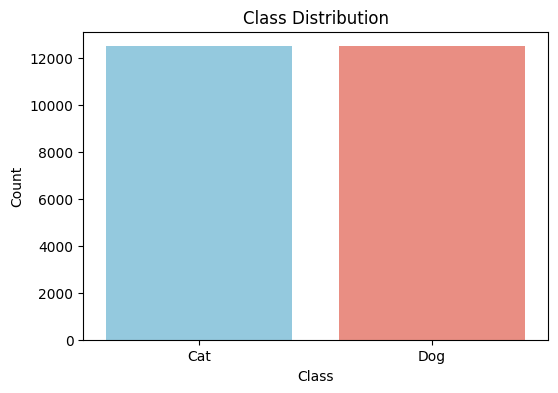

label
Cat    12499
Dog    12499
Name: count, dtype: int64


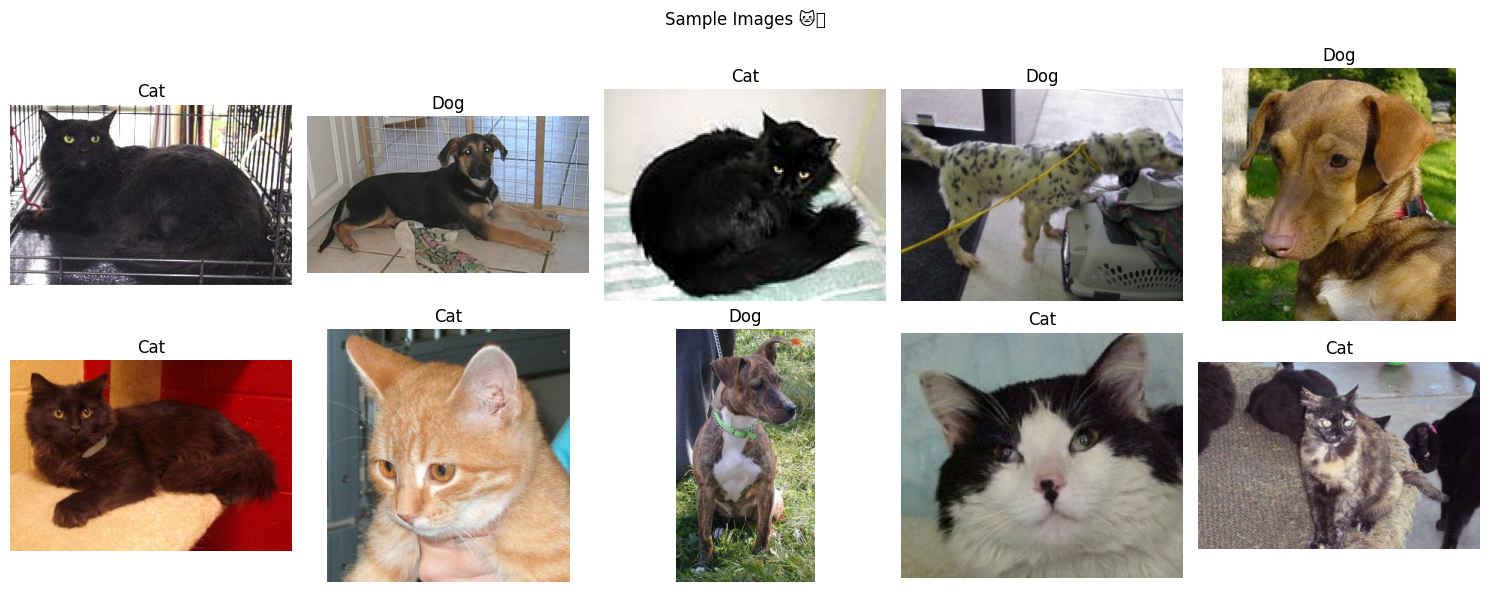

In [3]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=data, palette=["skyblue", "salmon"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(data["label"].value_counts())

# Sample images grid
plt.figure(figsize=(15,6))
sample_df = data.sample(10, random_state=SEED).reset_index(drop=True)

for i in range(10):
    plt.subplot(2, 5, i+1)
    img = Image.open(sample_df.loc[i, "filepath"])
    plt.imshow(img)
    plt.title(sample_df.loc[i, "label"])
    plt.axis("off")

plt.suptitle("Sample Images 🐱🐶")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Train / Validation / Test Split ✂️ </h2> </div>

We split the data into train, validation, and test sets using stratified sampling, so class balance is preserved across all three sets.

In [4]:
# First split: train vs temp (val+test)
train_df, temp_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data["label"],
    random_state=SEED
)

# Second split: temp -> val and test (50/50 of the 20%, i.e. 10% each)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

print("\nTrain class balance:\n", train_df["label"].value_counts(normalize=True))
print("\nValidation class balance:\n", val_df["label"].value_counts(normalize=True))
print("\nTest class balance:\n", test_df["label"].value_counts(normalize=True))

Train size: 19998
Validation size: 2500
Test size: 2500

Train class balance:
 label
Cat    0.5
Dog    0.5
Name: proportion, dtype: float64

Validation class balance:
 label
Dog    0.5
Cat    0.5
Name: proportion, dtype: float64

Test class balance:
 label
Dog    0.5
Cat    0.5
Name: proportion, dtype: float64


<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Image Data Generators 🖼️ </h2> </div>

We set up common image parameters and use `ImageDataGenerator` to load images directly from file paths using `flow_from_dataframe`. Augmentation (rotation, zoom, flip, shift) is applied only to the training set — validation and test sets are only rescaled.

In [5]:
# Parameters (used consistently everywhere)
IMG_SIZE = 128
IMG_CHANNELS = 3
BATCH_SIZE = 32

# Convert label column to string (flow_from_dataframe requirement)
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

# Training generator: with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Validation & test generators: rescale only, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

<h4 style="text-align:center;color:YELLOW"> Applying the Generators to Train / Val / Test 📂 </h4>

In [6]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Check class index mapping (important for interpreting predictions later)
print("Class indices:", train_generator.class_indices)

Found 19998 validated image filenames belonging to 2 classes.
Found 2500 validated image filenames belonging to 2 classes.
Found 2500 validated image filenames belonging to 2 classes.
Class indices: {'Cat': 0, 'Dog': 1}


<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> CNN Model Architecture 🧠 </h2> </div>

We build a CNN with repeated **Conv2D → BatchNormalization → MaxPooling2D → Dropout** blocks to extract features, followed by a Flatten and Dense layers. The output layer uses a single unit with **sigmoid** activation for binary classification (Cat = 0, Dog = 1, based on `class_indices` above).

In [7]:
model = Sequential(name="cats_vs_dogs_cnn")

# Block 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(IMG_SIZE, IMG_SIZE, IMG_CHANNELS)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# Block 4
model.add(Conv2D(256, (3,3), activation="relu", padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# Fully connected head
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer: 1 unit + sigmoid for binary classification
model.add(Dense(1, activation="sigmoid"))

model.summary()

I0000 00:00:1784388578.740742      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784388578.743845      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "cats_vs_dogs_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,586,177 (17.49 MB)

 Trainable params: 4,584,705 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Callbacks ⏱️ </h2> </div>

- **EarlyStopping**: stops training once validation loss stops improving, and restores the best weights.
- **ReduceLROnPlateau**: reduces the learning rate when validation accuracy plateaus, helping the model fine-tune.

In [9]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Compile & Train the Model 🚀 </h2> </div>

We compile with `binary_crossentropy` loss (matching our sigmoid output) and the Adam optimizer, then train for up to 20 epochs — EarlyStopping will cut training short if validation loss stops improving.

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
  1/625 ━━━━━━━━━━━━━━━━━━━━ 2:20:21 13s/step - accuracy: 0.5938 - loss: 1.0352

I0000 00:00:1784388646.813630     172 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 222ms/step - accuracy: 0.6360 - loss: 0.6909 - val_accuracy: 0.6448 - val_loss: 0.7158 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.7239 - loss: 0.5439 - val_accuracy: 0.7680 - val_loss: 0.4732 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.7671 - loss: 0.4845 - val_accuracy: 0.7828 - val_loss: 0.4487 - learning_rate: 0.0010
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 204ms/step - accuracy: 0.7984 - loss: 0.4369 - val_accuracy: 0.7444 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.8194 - loss: 0.4000 - val_accuracy: 0.8468 - val_loss: 0.3504 - learning_rate: 0.0010
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.8378 - loss: 0.3649 - val_accuracy: 0.8680 - val_loss: 0.3097 - learning_rate: 0.0010
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 125s 200ms/step - accuracy: 0.8556 

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Save the Trained Model 💾 </h2> </div>

We save the model **immediately after training** to `/kaggle/working/`, so it survives kernel restarts and doesn't need to be retrained to run the later cells.

In [11]:
MODEL_PATH = "/kaggle/working/cats_dogs_model.h5"

model.save(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: /kaggle/working/cats_dogs_model.h5


<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Training Curves 📈 </h2> </div>

Let's plot training vs validation accuracy and loss across epochs to check for overfitting/underfitting.

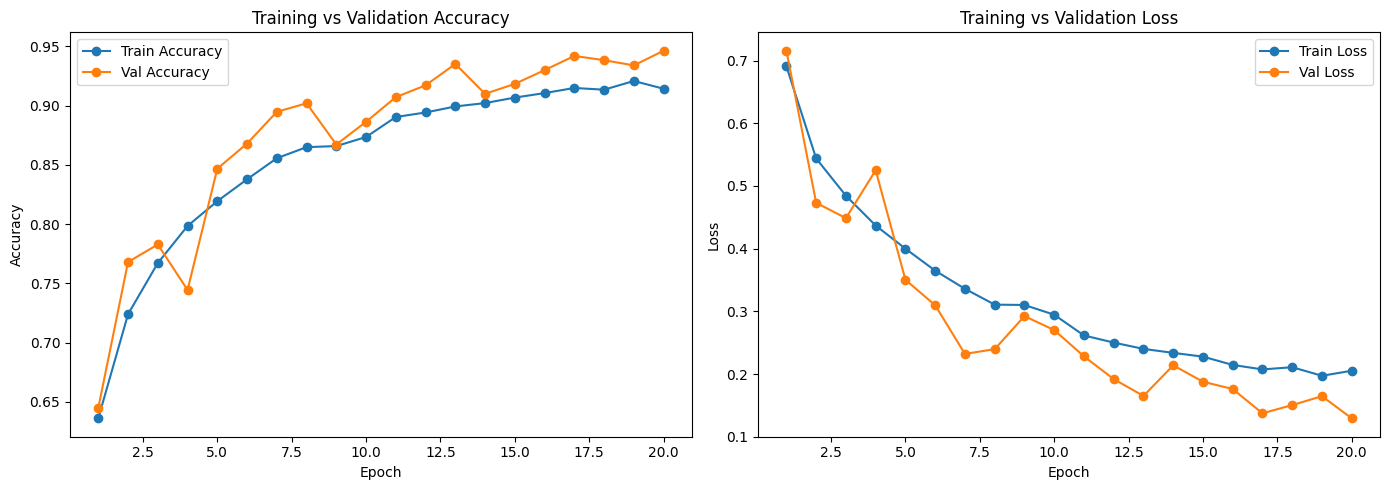

In [12]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Train Accuracy", marker="o")
plt.plot(epochs_range, val_acc, label="Val Accuracy", marker="o")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Train Loss", marker="o")
plt.plot(epochs_range, val_loss, label="Val Loss", marker="o")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Evaluation 🎯 </h2> </div>

Now we evaluate the trained model on the train, validation, and test sets to check overall performance and confirm there's no severe overfitting.

In [13]:
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss_final, val_acc_final = model.evaluate(val_generator, verbose=0)
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

print(f"Train Accuracy:      {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc_final*100:.2f}%")
print(f"Test Accuracy:       {test_acc*100:.2f}%")

print(f"\nTrain Loss:      {train_loss:.4f}")
print(f"Validation Loss: {val_loss_final:.4f}")
print(f"Test Loss:       {test_loss:.4f}")

Train Accuracy:      94.60%
Validation Accuracy: 94.64%
Test Accuracy:       94.08%

Train Loss:      0.1394
Validation Loss: 0.1293
Test Loss:       0.1558


<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Classification Report & Confusion Matrix 📊 </h2> </div>

We generate predictions on the test set and evaluate performance with a classification report (precision, recall, F1-score) and a confusion matrix.

79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step
Classification Report:

              precision    recall  f1-score   support

         Cat       0.94      0.95      0.94      1250
         Dog       0.95      0.94      0.94      1250

    accuracy                           0.94      2500
   macro avg       0.94      0.94      0.94      2500
weighted avg       0.94      0.94      0.94      2500



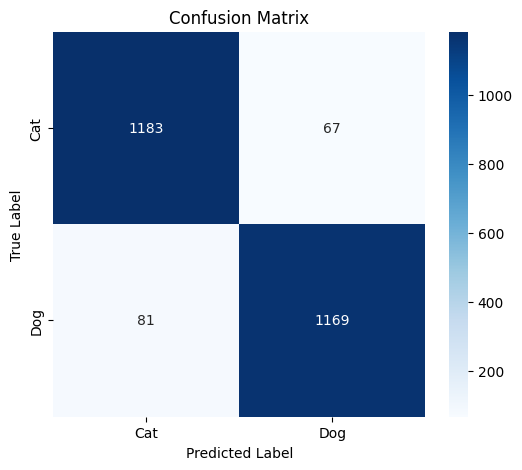

In [14]:
# Get true labels and class mapping
class_indices = train_generator.class_indices          # e.g. {'Cat': 0, 'Dog': 1}
idx_to_class = {v: k for k, v in class_indices.items()}

test_generator.reset()
y_true = test_generator.classes

# Predict probabilities on test set
y_pred_probs = model.predict(test_generator, verbose=1).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

target_names = [idx_to_class[0], idx_to_class[1]]

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Visualizing Test Predictions 🖼️ </h2> </div>

Here's a grid of 10 random test images with their true label vs the model's predicted label — correct predictions in **green**, wrong ones in **red**.

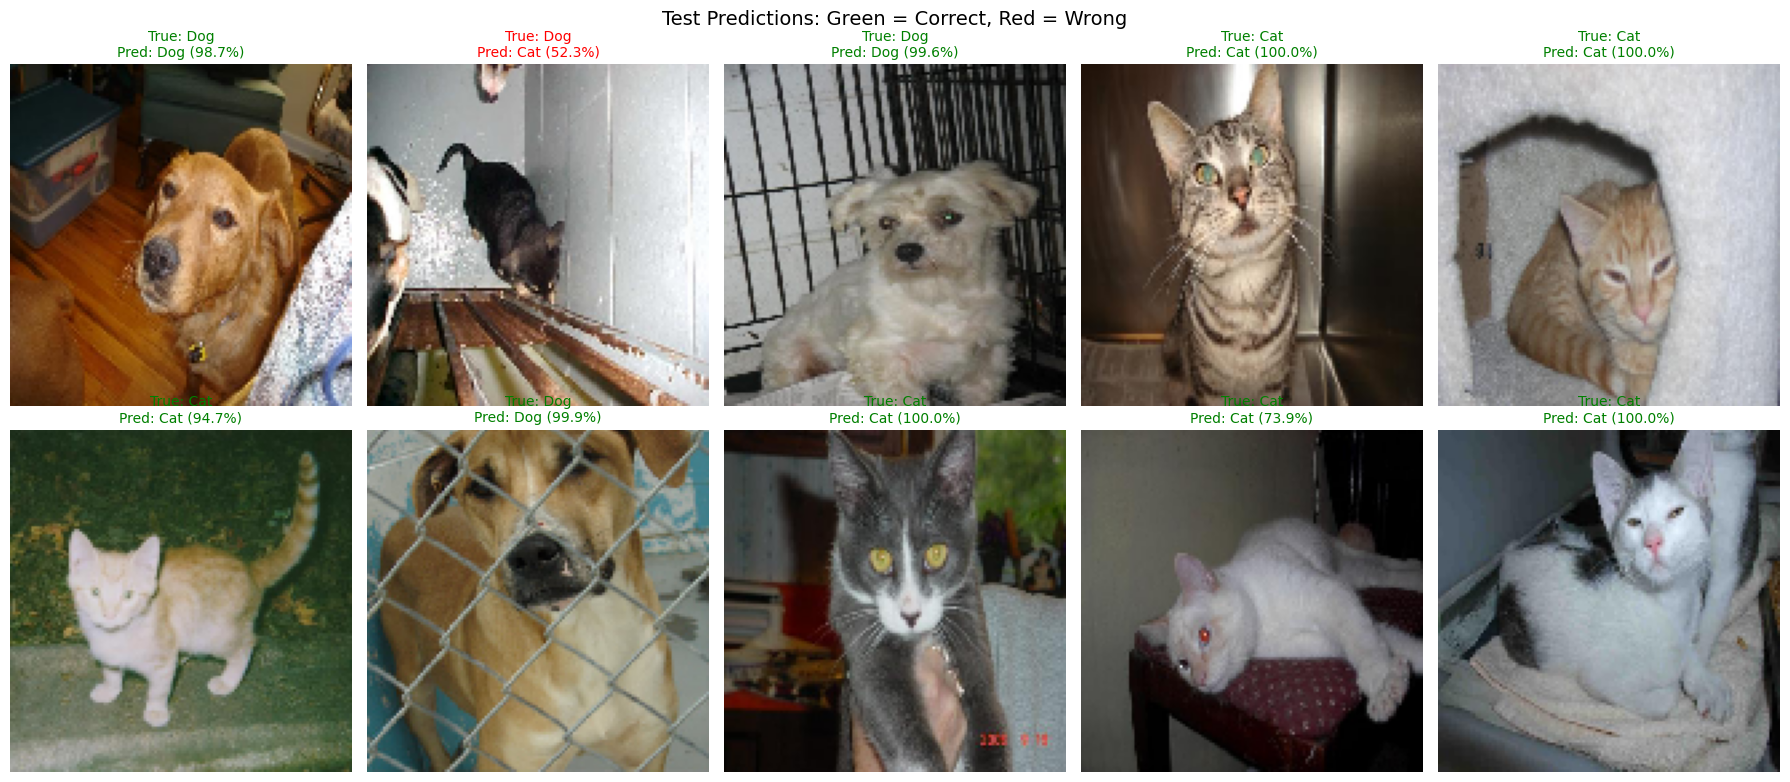

In [15]:
# Pick 10 random indices from the test set
sample_indices = random.sample(range(len(test_df)), 10)

plt.figure(figsize=(18,8))

for plot_i, idx in enumerate(sample_indices):
    filepath = test_df.loc[idx, "filepath"]
    true_label = test_df.loc[idx, "label"]

    # Load & preprocess single image the same way the generator does
    img = load_img(filepath, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    pred_prob = model.predict(img_batch, verbose=0)[0][0]
    pred_class = idx_to_class[int(pred_prob > 0.5)]
    confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

    is_correct = (pred_class == true_label)
    color = "green" if is_correct else "red"

    plt.subplot(2, 5, plot_i + 1)
    plt.imshow(img)
    plt.title(f"True: {true_label}\nPred: {pred_class} ({confidence*100:.1f}%)",
              color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Test Predictions: Green = Correct, Red = Wrong", fontsize=14)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Single-Image Prediction Function 🔮 </h2> </div>

A reusable function that takes any image file path, runs it through our trained `model`, and displays the image with the predicted class and confidence — e.g. "Model says: Dog (94.2% sure)".

In [17]:
def predict_image(image_path, model=model, img_size=IMG_SIZE, idx_to_class=idx_to_class):
    """
    Loads an image from `image_path`, runs it through the trained `model`,
    and displays it with a title showing the predicted class and confidence.
    """
    # Load & preprocess image (same pipeline as training)
    img = load_img(image_path, target_size=(img_size, img_size))
    img_array = img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    pred_prob = model.predict(img_batch, verbose=0)[0][0]

    if pred_prob > 0.5:
        pred_class = idx_to_class[1]
        confidence = pred_prob
    else:
        pred_class = idx_to_class[0]
        confidence = 1 - pred_prob

    # Display
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Model says: {pred_class} ({confidence*100:.1f}% sure)", fontsize=12)
    plt.show()

    print(f"Predicted class: {pred_class}")
    print(f"Confidence: {confidence*100:.2f}%")

    return pred_class, confidence

<h4 style="text-align:center;color:yellow"> Demo: Predicting an Unseen Image from the Test Set 🧪 </h4>

Actual label (ground truth): Dog
Image path: /kaggle/input/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/PetImages/Dog/909.jpg



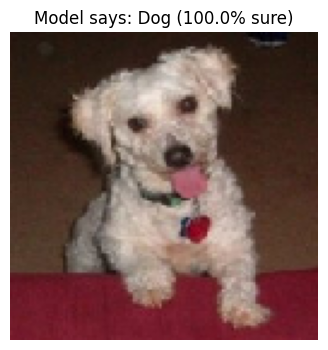

Predicted class: Dog
Confidence: 100.00%


In [18]:
# Pick a random unseen image from the held-out test set for a live demo
demo_row = test_df.sample(1, random_state=random.randint(0, 10000)).iloc[0]
demo_path = demo_row["filepath"]
actual_label = demo_row["label"]

print(f"Actual label (ground truth): {actual_label}")
print(f"Image path: {demo_path}\n")

predicted_class, confidence = predict_image(demo_path)

<div class="alert alert-block alert-info"><h2 style="text-align:center;color:black"> Conclusion 🏁 </h2> </div>

In this notebook, we built an end-to-end **Cats vs Dogs image classifier** using a custom CNN:

- Filtered ~25,000 raw images down to a clean, valid set by skipping corrupted files and `Thumbs.db`, since the raw dataset can't be modified in place.
- Split the data into stratified **train / validation / test** sets to keep class balance consistent.
- Used **augmented `ImageDataGenerator`** for training (rotation, zoom, flips, shifts) and plain rescaling for validation/test, to reduce overfitting.
- Built a **4-block CNN** (Conv2D + BatchNorm + MaxPooling + Dropout) with a sigmoid output for binary classification.
- Trained with **EarlyStopping** and **ReduceLROnPlateau**, then saved the model immediately to `/kaggle/working/cats_dogs_model.h5` so it survives kernel restarts.
- Evaluated performance with accuracy on all three sets, a **classification report**, and a **confusion matrix**.
- Visualized predictions on a sample grid (green = correct, red = wrong) and built a reusable **`predict_image()`** function for single-image inference, demoed live on an unseen test image.

### Possible Next Steps
- Try **transfer learning** (e.g. MobileNetV2, ResNet50, EfficientNet) for higher accuracy with less training time.
- Increase `IMG_SIZE` (e.g. 128 → 224) if GPU/time budget allows, since larger images usually help CNNs pick up finer detail.
- Add **test-time augmentation (TTA)** to slightly boost test accuracy.
- Export the model in the native Keras format (`.keras`) instead of `.h5`, since `.h5` is now considered legacy by Keras.
- Deploy `predict_image()` behind a simple **Gradio/Streamlit app** for interactive use outside Kaggle.

Thanks for following along! 🐱🐶